# 예상 대비 거래 차이 기반 군집화

회귀(`04_regression_3`)의 최종 모델로 **예측 거래건수**를 구한 뒤,
**예상 대비 거래 차이(= 실제 − 예측)** 를 기준으로 고객을 세그먼트합니다.

| 항목 | 설정 |
|---|---|
| 주제 | 예상 대비 거래 차이 군집 |
| 회귀 모델 | GridSearchCV `XGBRegressor` (`n_estimators=500`, `max_depth=5`, `learning_rate=0.01`, `subsample=0.8`) |
| 분할 | Train / Validation / Test = **6 : 2 : 2**, `random_state=42` |
| 목표 | Silhouette **≥ 0.4** |

## 0. 라이브러리 & 데이터 로드
회귀와 동일한 정제 데이터를 사용합니다.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.shape

(10127, 20)

## 1. 피처 엔지니어링 (회귀와 동일)
거래건수 타겟과 순환관계가 생기지 않도록, 인구·관계·시간 축 파생변수만 추가합니다.

- `리볼빙_한도_비율` = Total_Revolving_Bal / Credit_Limit
- `상품당_관계밀도` = Total_Relationship_Count / Months_on_book
- `문의_대비_보유기간` = Contacts_Count_12_mon / Months_on_book
- `연령대` = Customer_Age 구간화

제외: `Total_Trans_Ct`(타겟), `Target`(분류 타겟), `Total_Ct_Chng_Q4_Q1`(누수 위험)

In [6]:
df_fe = df.copy()

df_fe["리볼빙_한도_비율"] = df_fe["Total_Revolving_Bal"] / df_fe["Credit_Limit"]
df_fe["상품당_관계밀도"] = df_fe["Total_Relationship_Count"] / df_fe["Months_on_book"]
df_fe["문의_대비_보유기간"] = df_fe["Contacts_Count_12_mon"] / df_fe["Months_on_book"]
df_fe["연령대"] = pd.cut(
    df_fe["Customer_Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["20대이하", "30대", "40대", "50대", "60대이상"],
)

X = df_fe.drop(columns=["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"])
y = df_fe["Total_Trans_Ct"]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
y.describe()

X shape: (10127, 37)


C:\Users\playdata2\AppData\Local\Temp\ipykernel_22552\4113493577.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


count    10127.000000
mean        64.858695
std         23.472570
min         10.000000
25%         45.000000
50%         67.000000
75%         81.000000
max        139.000000
Name: Total_Trans_Ct, dtype: float64

행10127-고객수   
열 37 - 파생변수 + 원-핫인코딩까지 반영된 피처 개수


## 2. Train / Validation / Test = 6 : 2 : 2 (`seed=42`)
회귀 노트북과 동일한 분할을 유지합니다.

1. 전체 → (Train+Val) 80% : Test 20%
2. (Train+Val) → Train 75% : Val 25%  → 전체 기준 **60% : 20% : 20%**

In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train: 6075 (60.0%)
Validation: 2026 (20.0%)
Test: 2026 (20.0%)


## 3. 회귀 최종 모델 학습 → 예측 거래건수
회귀에서 확정한 GridSearchCV 최적 파라미터로 `XGBRegressor`를 학습합니다.

- 학습: **Train+Validation** (회귀 노트북의 GridSearchCV `refit`과 동일)
- 예측/군집 대상: **Test** (미사용 데이터로 갭·세그먼트 검증)

In [8]:
final_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    random_state=SEED,
)
final_model.fit(X_trainval, y_trainval)

y_pred_test = final_model.predict(X_test)

print(f"Test R²: {r2_score(y_test, y_pred_test):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")

Test R²: 0.8578
Test MAE: 6.96


test 셋에서 회귀 모델 XGBRegressor 얼마나 잘 맞혔는지 보는 지표

Test R² = 0.8578
- 거래건수 변동의 약 **85.8%**를 모델이 설명한다는 뜻

Test MAE = 6.96
- 예측이 평균적으로 실제보다 약 7건 정도 틀림
- 거래건수 평균이 ~65건이니, 대략 ±7건 오차

정리하면: “안 본 Test 고객에서도 거래건수를 꽤 잘 맞춘다”는 신호라, 이 예측으로 예상 대비 거래 차이를 만들어도 됩니다.

안 본 test 고객 = 모델을 학습할 때 쓰지 않은 고객(일부러 빼둔 고객, 나중에 예측시 사용)

## 4. 예상 대비 거래 차이 계산

$$
\text{예상 대비 거래 차이} = \text{실제 거래건수} - \text{예측 거래건수}
$$

- **큰 음수**: 예상보다 거래를 훨씬 덜 함 → 조기경보 후보
- **0 근처**: 예상과 비슷한 활동
- **양수**: 예상보다 더 활발

In [9]:
cluster_df = pd.DataFrame({
    "실제_거래건수": y_test.values,
    "예측_거래건수": y_pred_test,
    "예상_대비_거래_차이": y_test.values - y_pred_test,
    "실제_이탈여부": df.loc[X_test.index, "Target"].values,
}, index=X_test.index)

cluster_df.describe()[["실제_거래건수", "예측_거래건수", "예상_대비_거래_차이"]].round(2)

,실제_거래건수,예측_거래건수,예상_대비_거래_차이
count,2026.00,2026.00,2026.00
mean,64.66,64.77,-0.11
std,23.14,21.57,8.72
min,10.00,17.71,-30.90
25%,45.00,45.22,-6.04
50%,67.00,70.84,-0.17
75%,80.00,77.76,5.86
max,131.00,116.93,30.96


count=2026 test 고객 수(전체 20%)  
mean 실제 - 예측  차이 mean = -0.11
평균적으로 예측이 크게 치우치지 않음 (좋음)   
큰 음수 쪽(min, 25%)
예상보다 훨씬 덜 쓰는 고객이 있다는 신호 → 나중에 “우선케어” 후보

## 5. 군집 피처 선택 & 스케일링
실루엣 ≥ 0.4를 목표로, 주제와 직결된 2개 피처만 사용합니다.

| 피처 | 이유 |
|---|---|
| `예상_대비_거래_차이` | 군집 주제 (예상 대비 얼마나 덜/더 쓰는지) |
| `실제_거래건수` | 절대 활동 수준 (원래 저활동 vs 급감 구분) |

> 피처를 많이 넣으면 실루엣이 0.2대까지 떨어지므로, 해석·품질을 위해 2차원으로 유지합니다.

피처=나이,한도 거래건수, 예상 대비 차이 등

In [10]:
cluster_cols = ["예상_대비_거래_차이", "실제_거래건수"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_cols])

pd.DataFrame(X_scaled, columns=cluster_cols).describe().round(2)

,예상_대비_거래_차이,실제_거래건수
count,2026.00,2026.00
mean,-0.00,0.00
std,1.00,1.00
min,-3.53,-2.36
25%,-0.68,-0.85
50%,-0.01,0.10
75%,0.69,0.66
max,3.56,2.87


## 6. 최적 k 탐색 (Silhouette ≥ 0.4)
k=2~6을 비교해 실루엣이 0.4 이상인 후보 중 가장 높은 k를 선택합니다.

,k,silhouette,목표달성
0,2,0.393697,False
1,3,0.405685,True
2,4,0.378278,False
3,5,0.383291,False
4,6,0.370357,False


선택 k = 3 (silhouette = 0.4057)


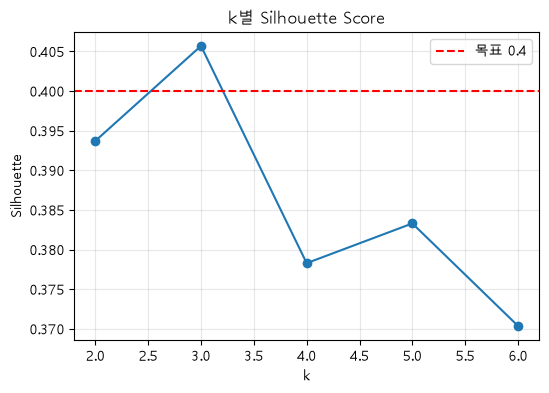

In [11]:
sil_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_rows.append({"k": k, "silhouette": sil, "목표달성": sil >= 0.4})

sil_df = pd.DataFrame(sil_rows)
display(sil_df)

ok = sil_df.loc[sil_df["목표달성"]]
if ok.empty:
    raise ValueError("Silhouette 0.4 이상인 k가 없습니다. 피처를 줄여 다시 시도하세요.")

BEST_K = int(ok.loc[ok["silhouette"].idxmax(), "k"])
print(f"선택 k = {BEST_K} (silhouette = {ok['silhouette'].max():.4f})")

plt.figure(figsize=(6, 4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.axhline(0.4, color="red", linestyle="--", label="목표 0.4")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("k별 Silhouette Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

k=2 0.39 목표 미달   
k=3 0.41 선택 3개 그룹으로 나누느 게 가장 깔끔하다.

## 7. 최종 KMeans 적합
선택한 k로 군집 라벨을 부여합니다.

In [12]:
kmeans = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, cluster_df["Cluster"])
print(f"최종 Silhouette: {final_sil:.4f}")
print(cluster_df["Cluster"].value_counts().sort_index())

최종 Silhouette: 0.4057
Cluster
0    634
1    671
2    721
Name: count, dtype: int64


세 그룹으로 나누어 균형적이게 됨  


## 8. 군집 신용카드 해지율
군집별 평균 차이·거래건수·이탈률을 비교한 요약 결과표

In [23]:
profile = cluster_df.groupby("Cluster").agg(
    인원=("예상_대비_거래_차이", "size"),
    평균_실제예측거래차이=("예상_대비_거래_차이", "mean"),
    평균_실제거래=("실제_거래건수", "mean"),
    평균_예측거래=("예측_거래건수", "mean"),
    신용카드해지율=("실제_이탈여부", "mean"),
).round(2)
profile["신용카드해지율(%)"] = (profile["신용카드해지율"] * 100).round(1)
profile = profile.drop(columns=["신용카드해지율"])
profile

,인원,평균_실제예측거래차이,평균_실제거래,평균_예측거래,신용카드해지율(%)
Cluster,,,,,
0,634,-1.57,37.70,39.259998,36.0
1,671,-7.47,69.82,77.290001,11.0
2,721,8.02,83.57,75.550003,4.0


이탈률-실제 이탈여부로만 계산 

| Cluster | 특징 | 해석 |
|---------|------|------|
| **0** | 거래 적음(≈38), 차이≈0, 이탈률 36% | 원래 저활동 + 이탈 많음. “급한 급감”보다 만성 저이용·고위험 |
| **1** | 거래 보통(≈70), 차이 −7.5(예상보다 덜 씀), 이탈 11% | 우선케어 후보 — 아직 많이 쓰지만 예상보다 줄어든 그룹 |
| **2** | 거래 많음(≈84), 차이 +8(예상보다 더 씀), 이탈 4% | 우량 — 활발하고 이탈 낮음 |

신용카드를 해지 이탈한 고객 비율 차이라서 음수를 기준

## 비지니스 해석

In [27]:
# 우선케어군이 이탈율이 적고 ,보통이 많음
# 평균_차이(음수일수록 예상보다 덜 씀) 기준으로 라벨 부여
order = profile["평균_실제예측거래차이"].sort_values().index.tolist()
label_map = {}
names = ["우선케어(활동급감대응)", "저활동/고위험(유지대응)", "우량/예상이상"]
for i, c in enumerate(order):
    label_map[c] = names[i] if i < len(names) else f"고객군_{i}"

cluster_df["고객군"] = cluster_df["Cluster"].map(label_map)
print(label_map)
cluster_df.groupby("고객군").agg(
    인원=("예상_대비_거래_차이", "size"),
    평균_실제예측거래차이=("예상_대비_거래_차이", "mean"),
    평균_실제거래=("실제_거래건수", "mean")
).sort_values("평균_실제예측거래차이")

{1: '우선케어(활동급감대응)', 0: '저활동/고위험(유지대응)', 2: '우량/예상이상'}


,인원,평균_실제예측거래차이,평균_실제거래
고객군,,,
우선케어(활동급감대응),671,-7.471303,69.822653
저활동/고위험(유지대응),634,-1.568052,37.695584
우량/예상이상,721,8.019244,83.572816


## 9. 시각화
2개 피처이므로 산점도로 바로 확인하고, 참고용 PCA도 함께 봅니다.
- PCA : 2차원 요약

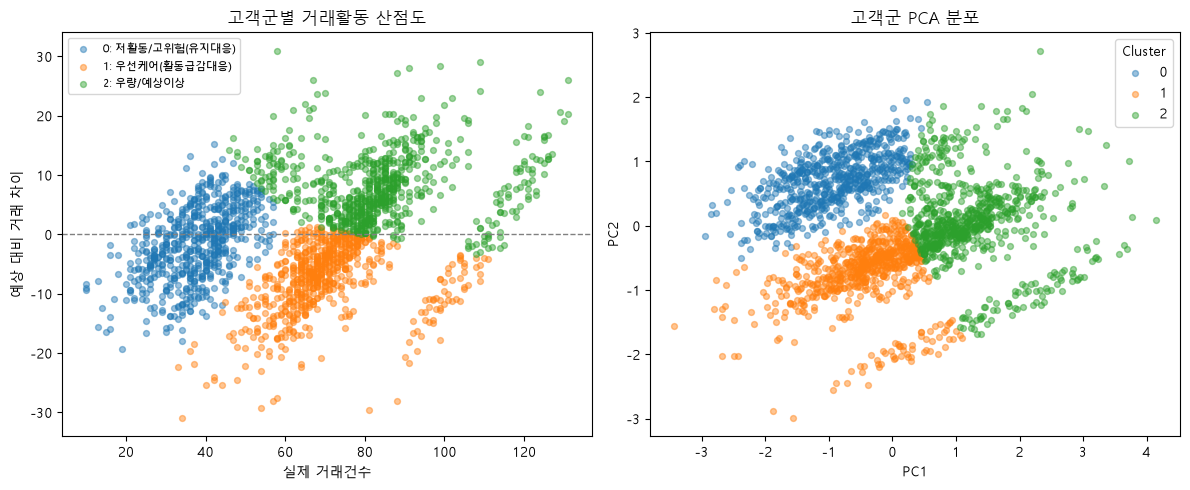

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(cluster_df["Cluster"].unique()):
    mask = cluster_df["Cluster"] == c
    axes[0].scatter(
        cluster_df.loc[mask, "실제_거래건수"],
        cluster_df.loc[mask, "예상_대비_거래_차이"],
        alpha=0.45, s=18, label=f"{c}: {label_map[c]}",
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_xlabel("실제 거래건수")
axes[0].set_ylabel("예상 대비 거래 차이")
axes[0].set_title("고객군별 거래활동 산점도")
axes[0].legend(fontsize=8)

pca = PCA(n_components=2, random_state=SEED)
xy = pca.fit_transform(X_scaled)
for c in sorted(cluster_df["Cluster"].unique()):
    mask = cluster_df["Cluster"] == c
    axes[1].scatter(xy[mask, 0], xy[mask, 1], alpha=0.45, s=18, label=str(c))
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("고객군 PCA 분포")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

# 산점도 설명
## 왼쪽 — 고객군별 거래활동 산점도
| 축 | 의미 |
|----|------|
| X축 실제 거래건수 | 카드를 얼마나 썼는지 |
| Y축 예상 대비 거래 차이 | 실제 − 예측 (`0` 점선 = 예상과 동일) |
| Y > 0 | 예상보다 **더** 씀 |
| Y < 0 | 예상보다 **덜** 씀 |
### 색별로 한 줄
- **파랑(0) 저활동/고위험:** 왼쪽(거래 적음), Y≈0 근처 → 원래 적게 쓰는 그룹
- **주황(1) 우선케어:** 가운데~오른쪽인데 거의 전부 점선 아래 → 거래는 있는데 예상보다 많이 부족 (= 활동 급감)
- **초록(2) 우량:** 오른쪽 + 점선 위 → 많이 쓰고 예상 이상
> “나중에 늘어난다”가 아니라, **지금 시점에서 기대치보다 덜/더 썼는지**를 그린 그림입니다.
---
## 오른쪽 — 고객군 PCA 분포 (PCA 2D)
거래·차이 정보를 2차원으로 압축해 **세 군집이 겹치지 않고 갈렸는지** 보는 그림입니다.
파랑 / 주황 / 초록이 구역이 다르면 → 군집 분리가 잘 된 것.
---
## 말할 때 한줄 요약
> 왼쪽은 **누가 거래를 적게/많이, 예상보다 덜/더 쓰는지** 보여주는 케어용 그림이고, 오른쪽은 **그 그룹이 통계적으로도 잘 나뉘었는지** 확인하는 그림입니다.


## 10. 군집별 Silhouette 점검
전체 실루엣과 군집별 평균 실루엣을 확인합니다.

In [17]:
sil_samples = silhouette_samples(X_scaled, cluster_df["Cluster"])
sil_by_cluster = (
    pd.DataFrame({"Cluster": cluster_df["Cluster"].values, "silhouette": sil_samples})
    .groupby("Cluster")["silhouette"]
    .mean()
    .round(3)
)
print(f"전체 Silhouette: {final_sil:.4f}")
sil_by_cluster

전체 Silhouette: 0.4057


Cluster
0    0.443
1    0.386
2    0.391
Name: silhouette, dtype: float64

## 11. 요약

1. 회귀와 동일한 FE + **6:2:2 / seed=42** 분할
2. 최종 `XGBRegressor`로 Test 예측 거래건수 산출
3. **예상 대비 거래 차이 = 실제 − 예측** 계산
4. `예상_대비_거래_차이 + 실제_거래건수`로 KMeans
5. Silhouette **≥ 0.4**인 k 선택 → 세그먼트별 이탈률·케어 우선순위 해석

**실무 포인트:** 차이가 큰 음수인 군집은 “아직 이탈 전이지만 예상보다 활동이 급감한 고객”이므로 유지 캠페인 우선 대상입니다.